# 06: PCA com Embeddings Faciais - Conceito

Este notebook ilustra como PCA pode ser usado para visualizar similaridade entre embeddings faciais.
**Prévia:** Na aula de Deep Learning, vocês aprenderão a gerar embeddings com CNNs. Aqui vemos como visualizá-los.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11

## 1. Conceito: O que são Embeddings Faciais?

In [2]:
# Explicação conceitual
print("=" * 60)
print("EMBEDDINGS FACIAIS")
print("=" * 60)
print("""
Imagine que você tem uma foto de um rosto. Para um computador,
essa foto é apenas uma matriz de pixels. Não significa nada.

Um embedding é uma REPRESENTAÇÃO NUMÉRICA do rosto que
captura suas características importantes (distâncias entre
olhos, forma do nariz, textura, etc).

Exemplo:
  - Foto → Embedding (128 números)
  - [0.23, -0.45, 0.78, ..., 0.12]  (128-dimensional)

Rostos similares têm embeddings próximos no espaço!
""")

EMBEDDINGS FACIAIS

Imagine que você tem uma foto de um rosto. Para um computador,
essa foto é apenas uma matriz de pixels. Não significa nada.

Um embedding é uma REPRESENTAÇÃO NUMÉRICA do rosto que
captura suas características importantes (distâncias entre
olhos, forma do nariz, textura, etc).

Exemplo:
  - Foto → Embedding (128 números)
  - [0.23, -0.45, 0.78, ..., 0.12]  (128-dimensional)

Rostos similares têm embeddings próximos no espaço!



## 2. Simulando Embeddings Faciais

In [3]:
# Simular embeddings faciais (para fins educacionais)
# Na prática, usaríamos uma rede neural (CNN) para gerar esses embeddings

np.random.seed(42)

# Simular 8 pessoas com embeddings 128D
# Cada pessoa tem um "centro" no espaço 128D
n_people = 8
embedding_dim = 128

# Centros (personas distintas)
centers = np.random.randn(n_people, embedding_dim)

# Variação intra-pessoa (mesma pessoa, fotos diferentes)
n_photos_per_person = 5
variance = 0.3

# Gerar fotos
embeddings = []
labels = []

for person_id in range(n_people):
    for photo_id in range(n_photos_per_person):
        embedding = centers[person_id] + np.random.randn(embedding_dim) * variance
        embeddings.append(embedding)
        labels.append(person_id)

embeddings = np.array(embeddings)
labels = np.array(labels)

print(f"Total de embeddings: {embeddings.shape[0]}")
print(f"Dimensão de cada embedding: {embeddings.shape[1]}")
print(f"Pessoas: {n_people}")
print(f"Fotos por pessoa: {n_photos_per_person}")

Total de embeddings: 40
Dimensão de cada embedding: 128
Pessoas: 8
Fotos por pessoa: 5


In [4]:
# Calcular distâncias entre pessoas (centroides)
from scipy.spatial.distance import cdist

centeroids = []
for i in range(n_people):
    mask = labels == i
    centeroids.append(embeddings[mask].mean(axis=0))
centeroids = np.array(centeroids)

# Matriz de distâncias
distance_matrix = cdist(centeroids, centeroids, metric='cosine')

print("Matriz de Distância Cosseno entre Personas:")
print(f"Formato: {distance_matrix.shape}")
print(f"\nDistância média entre pessoas: {distance_matrix[distance_matrix > 0].mean():.3f}")

Matriz de Distância Cosseno entre Personas:
Formato: (8, 8)

Distância média entre pessoas: 0.997


## 3. PCA para Visualizar Embeddings 128D → 2D

In [5]:
# Aplicar PCA para reduzir de 128D para 2D
pca_embeddings = PCA(n_components=2)
embeddings_2d = pca_embeddings.fit_transform(embeddings)

print("PCA nos Embeddings:")
print(f"  Original: {embeddings.shape}")
print(f"  Reduzido: {embeddings_2d.shape}")
print(f"  Variância explicada: {pca_embeddings.explained_variance_ratio_.sum()*100:.1f}%")

PCA nos Embeddings:
  Original: (40, 128)
  Reduzido: (40, 2)
  Variância explicada: 34.4%


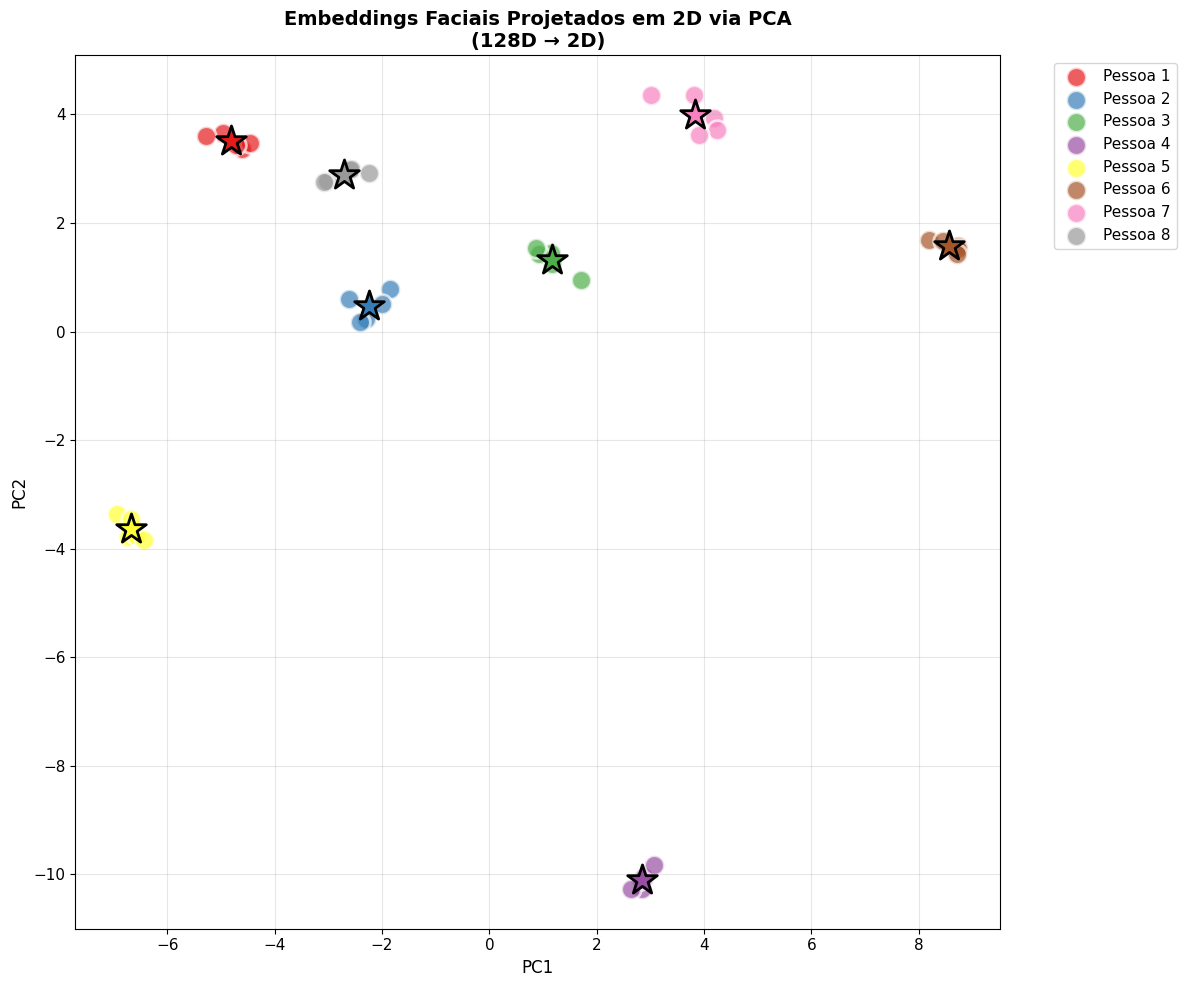

Gráfico salvo: ../graficos/embeddings_faciais_simulated.png


In [6]:
# Visualização 2D dos embeddings
fig, ax = plt.subplots(figsize=(12, 10))

colors = plt.cm.Set1(np.linspace(0, 1, n_people))

for person_id in range(n_people):
    mask = labels == person_id
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
               c=[colors[person_id]], s=200, alpha=0.7,
               label=f'Pessoa {person_id+1}', edgecolors='white', linewidth=2)

    # Marcador para o centroide
    centroid_2d = embeddings_2d[mask].mean(axis=0)
    ax.scatter(centroid_2d[0], centroid_2d[1], c=[colors[person_id]],
               s=500, marker='*', edgecolors='black', linewidth=2, zorder=10)

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('Embeddings Faciais Projetados em 2D via PCA\n(128D → 2D)', fontsize=14, fontweight='bold')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../graficos/embeddings_faciais_simulated.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: ../graficos/embeddings_faciais_simulated.png")

## 4. Similaridade Espacial no Espaço de Embeddings

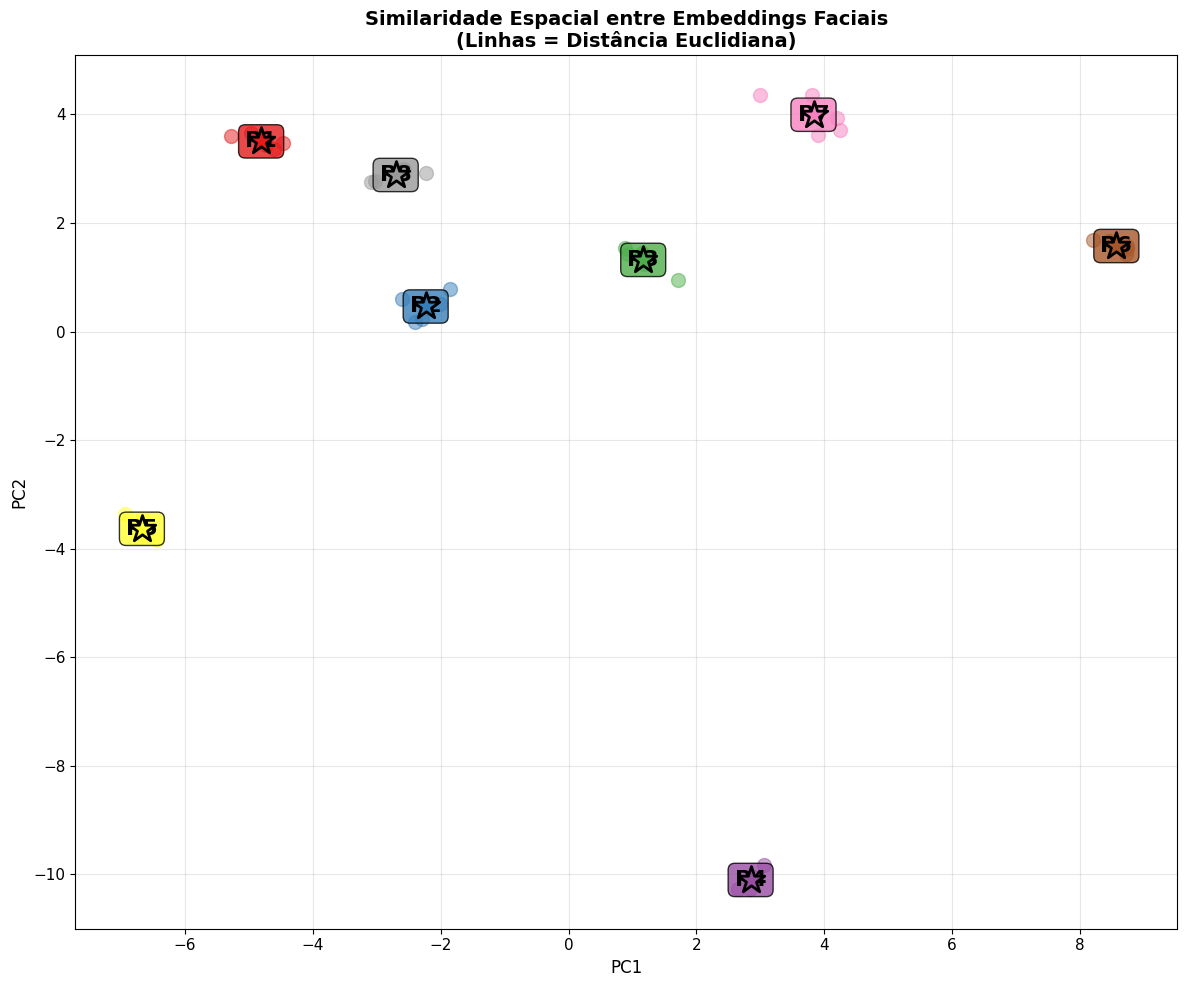

Gráfico salvo: ../graficos/similaridade_espacial.png


In [7]:
# Mostrar conceito de similaridade
# Pessoas próximas no espaço 2D são similares

fig, ax = plt.subplots(figsize=(12, 10))

# Plot com linhas conectando pessoas próximas
for person_id in range(n_people):
    mask = labels == person_id
    centroid = embeddings_2d[mask].mean(axis=0)
    
    # Nome da pessoa
    ax.annotate(f'P{person_id+1}', centroid, fontsize=16, fontweight='bold',
               ha='center', va='center',
               bbox=dict(boxstyle='round', facecolor=colors[person_id], alpha=0.8))

# Calcular distâncias entre centroides 2D
from scipy.spatial.distance import cdist
centroids_2d = np.array([embeddings_2d[labels == i].mean(axis=0) for i in range(n_people)])
dist_2d = cdist(centroids_2d, centroids_2d, metric='euclidean')

# Desenhar linhas entre pessoas mais próximas (threshold)
threshold = 1.5
for i in range(n_people):
    for j in range(i+1, n_people):
        if dist_2d[i, j] < threshold:
            ax.plot([centroids_2d[i, 0], centroids_2d[j, 0]],
                   [centroids_2d[i, 1], centroids_2d[j, 1]],
                   'k-', alpha=0.3, linewidth=2)
            ax.text((centroids_2d[i, 0] + centroids_2d[j, 0])/2,
                   (centroids_2d[i, 1] + centroids_2d[j, 1])/2,
                   f'{dist_2d[i,j]:.2f}', fontsize=9, alpha=0.7)

# Scatter final
for person_id in range(n_people):
    mask = labels == person_id
    ax.scatter(embeddings_2d[mask, 0], embeddings_2d[mask, 1],
               c=[colors[person_id]], s=100, alpha=0.5)
    ax.scatter(centroids_2d[person_id, 0], centroids_2d[person_id, 1],
               c=[colors[person_id]], s=400, marker='*', edgecolors='black', linewidth=2, zorder=10)

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('Similaridade Espacial entre Embeddings Faciais\n(Linhas = Distância Euclidiana)', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../graficos/similaridade_espacial.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: ../graficos/similaridade_espacial.png")

## 5. Prévia para a Aula de Deep Learning

In [8]:
print("=" * 60)
print("PRÓXIMA AULA: DEEP LEARNING PARA EMBEDDINGS")
print("=" * 60)
print("""
Neste notebook, simulamos embeddings para entender o conceito.

Na aula de Deep Learning, vocês aprenderão a:

1. Usar CNNs (Redes Neurais Convolucionais) para gerar
   embeddings faciais reais a partir de fotos

2. Arquiteturas como FaceNet, ArcFace, ou reconhecedor
   de faces do torchvision

3. O pipeline completo:
   Foto → CNN → Embedding 128D → Comparação

4. Aplicações: reconhecimento facial, verificação de identidade,
   clusterização de rostos, etc.

O PCA que vocês aprenderam HOJE é a mesma técnica que
será usada Amanhã para VISUALIZAR os embeddings gerados
pelas redes neurais!
""")

PRÓXIMA AULA: DEEP LEARNING PARA EMBEDDINGS

Neste notebook, simulamos embeddings para entender o conceito.

Na aula de Deep Learning, vocês aprenderão a:

1. Usar CNNs (Redes Neurais Convolucionais) para gerar
   embeddings faciais reais a partir de fotos

2. Arquiteturas como FaceNet, ArcFace, ou reconhecedor
   de faces do torchvision

3. O pipeline completo:
   Foto → CNN → Embedding 128D → Comparação

4. Aplicações: reconhecimento facial, verificação de identidade,
   clusterização de rostos, etc.

O PCA que vocês aprenderam HOJE é a mesma técnica que
será usada Amanhã para VISUALIZAR os embeddings gerados
pelas redes neurais!



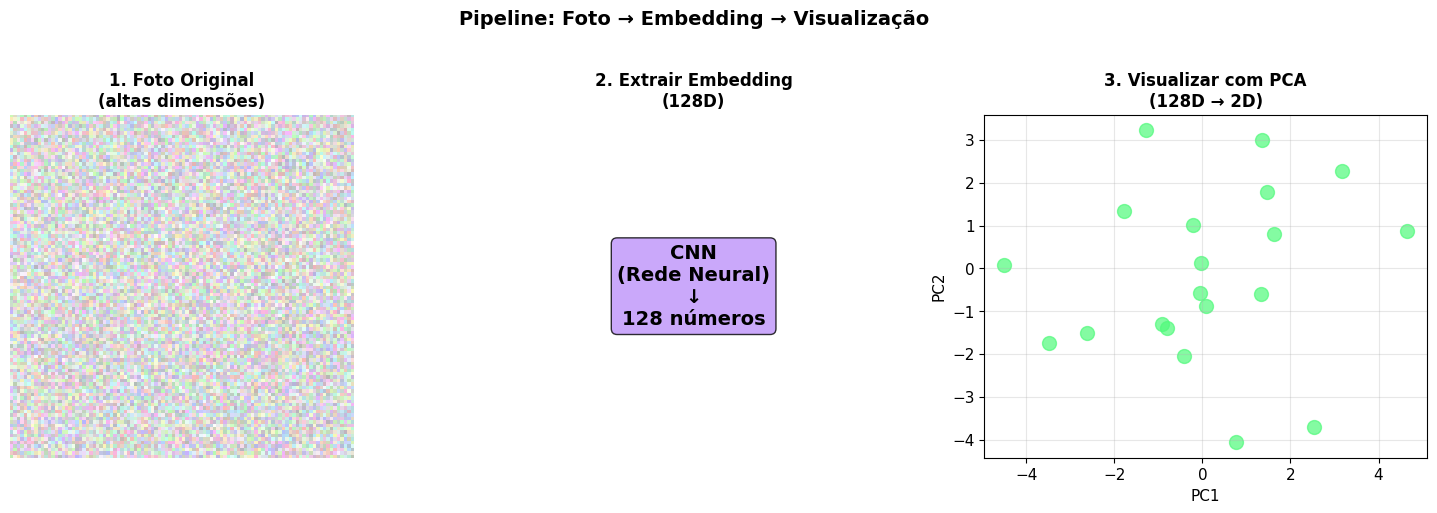

Gráfico salvo: ../graficos/pipeline_embeddings.png


In [9]:
# Visualização do pipeline completo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Passo 1: Foto
axes[0].imshow(np.random.rand(100, 100, 3) * 0.3 + 0.7, cmap='gray')
axes[0].set_title('1. Foto Original\n(altas dimensões)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Passo 2: CNN
axes[1].text(0.5, 0.5, 'CNN\n(Rede Neural)\n↓\n128 números', 
             ha='center', va='center', fontsize=14, fontweight='bold',
             transform=axes[1].transAxes,
             bbox=dict(boxstyle='round', facecolor='#bd93f9', alpha=0.8))
axes[1].set_title('2. Extrair Embedding\n(128D)', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Passo 3: PCA 2D
# Simular projeção
fake_2d = np.random.randn(20, 2) * 2
axes[2].scatter(fake_2d[:, 0], fake_2d[:, 1], c='#50fa7b', s=100, alpha=0.7)
axes[2].set_title('3. Visualizar com PCA\n(128D → 2D)', fontsize=12, fontweight='bold')
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].grid(True, alpha=0.3)

plt.suptitle('Pipeline: Foto → Embedding → Visualização', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../graficos/pipeline_embeddings.png', dpi=150, bbox_inches='tight')
plt.show()
print("Gráfico salvo: ../graficos/pipeline_embeddings.png")